<a href="https://colab.research.google.com/github/Raju-mia-RK/Raju/blob/colab_work/model_compersion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


In [4]:
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv('/content/drive/MyDrive/datasets/diabetes.csv')


Mounted at /content/drive


In [6]:
df.shape

(768, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
print(df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


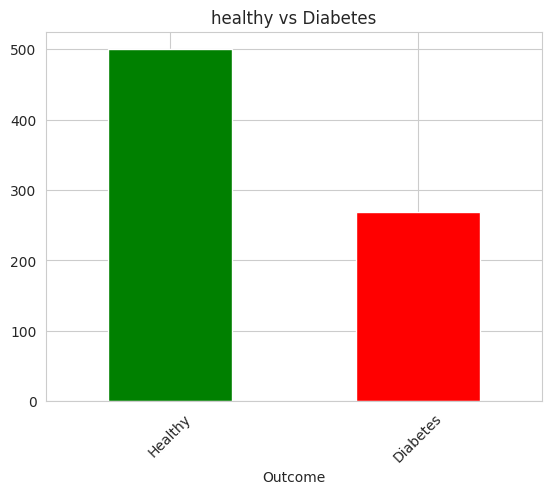

In [12]:
df['Outcome'].value_counts().plot(kind='bar',color=['green','red'])
plt.title('healthy vs Diabetes')
plt.xticks([0,1],['Healthy','Diabetes'],rotation=45)
plt.show()

In [13]:
X=df.drop('Outcome',axis=1)
Y=df['Outcome']
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,test_size=0.2,random_state=42
)
print(f'Trian data: {len(X_train)}')
print(f'Test data: {len(X_test)}')

Trian data: 614
Test data: 154


In [14]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

18


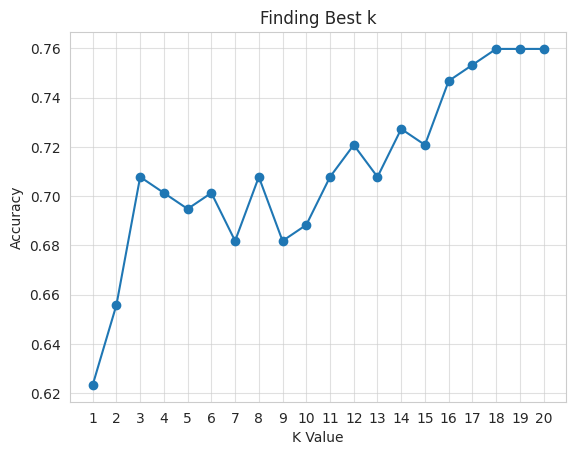

In [15]:
accuracies=[]
for k in range(1,21):
  knn=KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train_scaled,Y_train)
  X_pred=knn.predict(X_test_scaled)
  accuracies.append(accuracy_score(Y_test,X_pred))

best_k=accuracies.index(max(accuracies))+1
print(best_k)
plt.plot(range(1,21),accuracies,marker='o')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(range(1,21))
plt.title("Finding Best k")
plt.grid(alpha=0.6)
plt.show()

In [16]:
knn_model=KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled,Y_train)
X_pred=knn_model.predict(X_test_scaled)
knn_accuracy=accuracy_score(Y_test,X_pred)
print(f'Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)')

Accuracy: 0.7597 (75.97%)


              precision    recall  f1-score   support

     Healthy       0.77      0.89      0.83        99
    Diabetes       0.72      0.53      0.61        55

    accuracy                           0.76       154
   macro avg       0.75      0.71      0.72       154
weighted avg       0.76      0.76      0.75       154



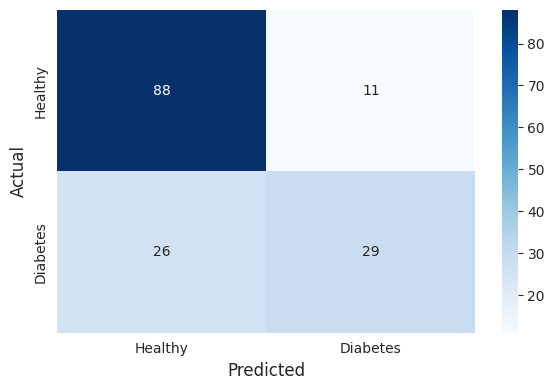

In [20]:
print(classification_report(Y_test,X_pred,target_names=['Healthy','Diabetes']))
cm_knn=confusion_matrix(Y_test,X_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Healthy','Diabetes'],
            yticklabels=['Healthy','Diabetes'])
#plt.title('KNN Confusion Matrix', fontsize=14 , fontweight='blod')
plt.ylabel('Actual',fontsize=12)
plt.xlabel('Predicted',fontsize=12)
plt.tight_layout()
plt.show()

In [26]:
print('Traning Decision Tree')
dt_model=DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    min_samples_split=20,
    min_samples_leaf=10,
    criterion='gini'
)
dt_model.fit(X_train,Y_train)
X_pred_dt=dt_model.predict(X_test)
dt_accuracy=accuracy_score(Y_test,X_pred_dt)
print(f'Decision Tree Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f})')

Traning Decision Tree
Decision Tree Accuracy: 0.7792 (77.92)


Decision Tree Classification Report: 
              precision    recall  f1-score   support

     Healthy       0.82      0.85      0.83        99
    Diabetes       0.71      0.65      0.68        55

    accuracy                           0.78       154
   macro avg       0.76      0.75      0.76       154
weighted avg       0.78      0.78      0.78       154



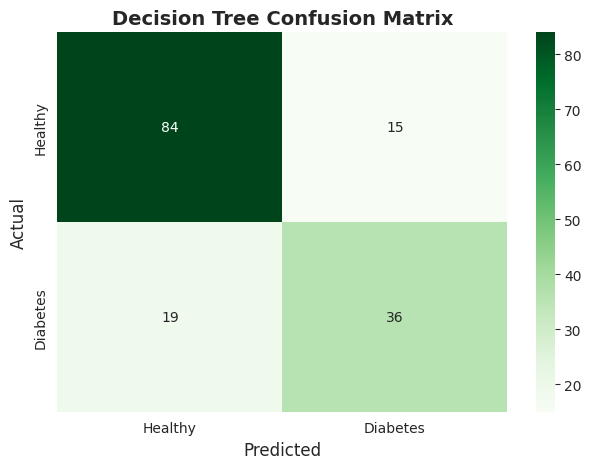

In [27]:
print('Decision Tree Classification Report: ')
print(classification_report(Y_test,X_pred_dt,target_names=['Healthy','Diabetes']))
cm_dt=confusion_matrix(Y_test,X_pred_dt)
sns.heatmap(cm_dt,annot=True,fmt='d',cmap='Greens',
            xticklabels=['Healthy','Diabetes'],
            yticklabels=['Healthy','Diabetes'])
plt.title('Decision Tree Confusion Matrix',fontsize=14,fontweight='bold')
plt.ylabel('Actual',fontsize=12)
plt.xlabel('Predicted',fontsize=12)
plt.tight_layout()
plt.show()

Feature Importance (Decision Tree)
                 Feature  Importance
                 Glucose    0.508972
                     BMI    0.200403
                     Age    0.136262
DiabetesPedigreeFunction    0.069366
                 Insulin    0.050283
           SkinThickness    0.023486
           BloodPressure    0.011229
             Pregnancies    0.000000


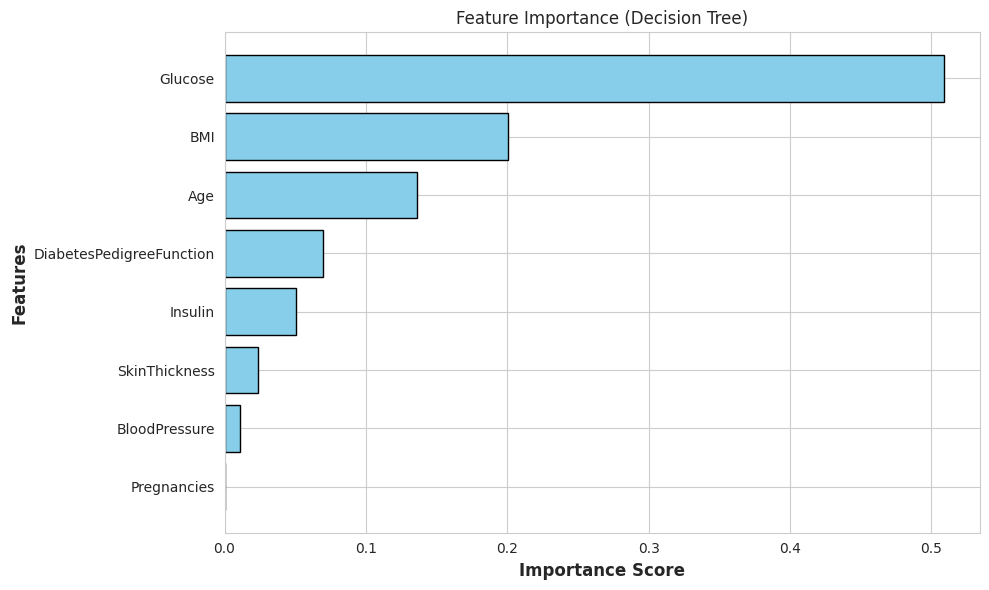

In [32]:
print('Feature Importance (Decision Tree)')
feature_importance=pd.DataFrame({
    'Feature': X.columns,
    'Importance':dt_model.feature_importances_
}).sort_values('Importance',ascending=False)
print(feature_importance.to_string(index=False))
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'],feature_importance['Importance'],color='skyblue',edgecolor='black')
plt.xlabel('Importance Score',fontsize=12,fontweight='bold')
plt.ylabel('Features',fontsize=12,fontweight='bold')
plt.title('Feature Importance (Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [33]:
rf_model=RandomForestClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    n_estimators=100
)
rf_model.fit(X_train,Y_train)
x_pred_rf=rf_model.predict(X_test)
rf_accuracy=accuracy_score(Y_test,x_pred_rf)
print(f'Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f})')

Random Forest Accuracy: 0.7727 (77.27)


              precision    recall  f1-score   support

     Healthy       0.80      0.86      0.83        99
    Diabetes       0.71      0.62      0.66        55

    accuracy                           0.77       154
   macro avg       0.76      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



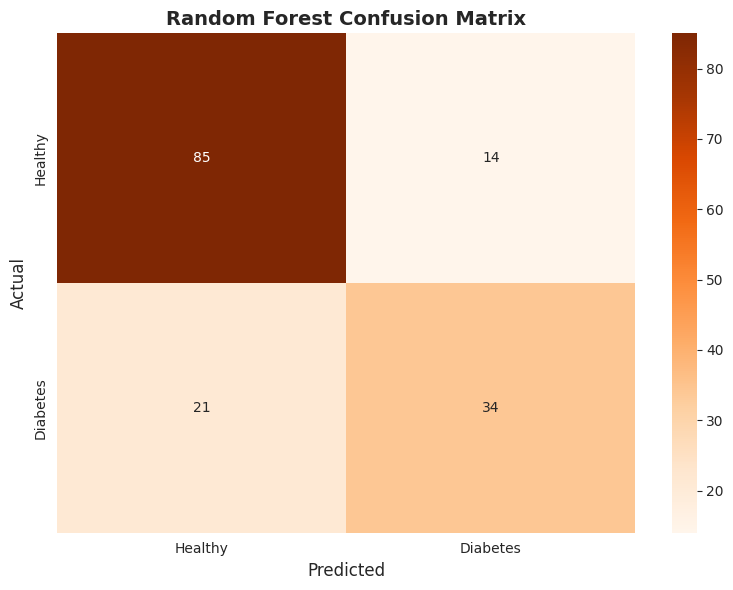

In [35]:
cm_rf=confusion_matrix(Y_test,x_pred_rf)
print(classification_report(Y_test,x_pred_rf,target_names=['Healthy','Diabetes']))
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Oranges',
            xticklabels=['Healthy','Diabetes'],
            yticklabels=['Healthy','Diabetes'])
plt.title('Random Forest Confusion Matrix',fontsize=14,fontweight='bold')
plt.ylabel('Actual',fontsize=12)
plt.xlabel('Predicted',fontsize=12)
plt.tight_layout
plt.tight_layout()
plt.show()

                 Feature  Importance
                 Glucose    0.383623
                     BMI    0.180074
                     Age    0.158372
DiabetesPedigreeFunction    0.076305
             Pregnancies    0.064759
                 Insulin    0.053778
           BloodPressure    0.041942
           SkinThickness    0.041147


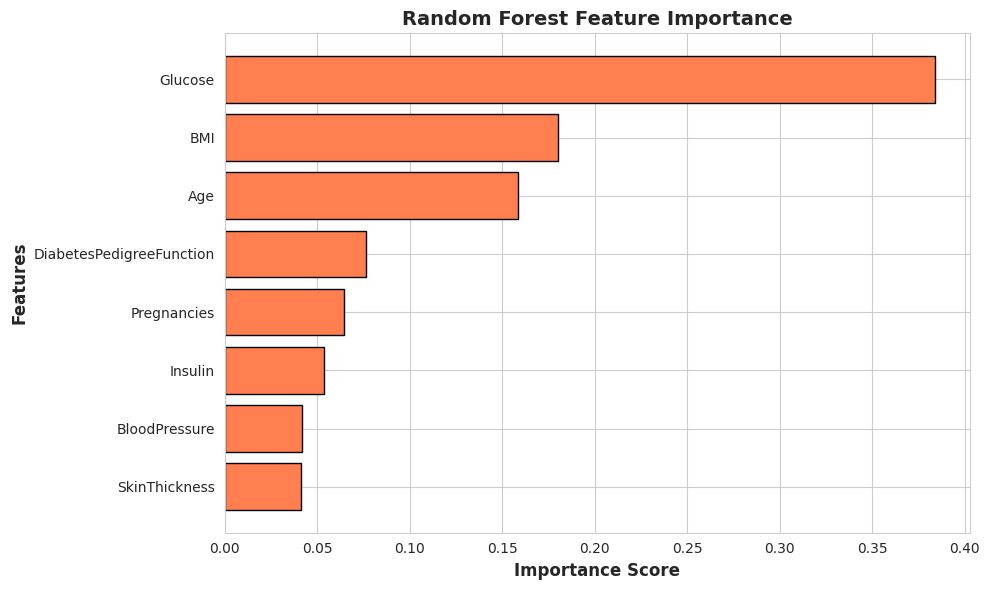

In [36]:
rf_feature_importance=pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_model.feature_importances_
}).sort_values('Importance',ascending=False)
print(rf_feature_importance.to_string(index=False))
plt.figure(figsize=(10,6))
plt.barh(rf_feature_importance['Feature'],rf_feature_importance['Importance'],color='coral',edgecolor='black')
plt.xlabel('Importance Score',fontsize=12,fontweight='bold')
plt.ylabel('Features',fontsize=12,fontweight='bold')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
print('Final Model Comparsion')
comparsion=pd.DataFrame({
    'Model':['KNN','Decision Tree','Random Forest'],
    'Accuracy':[knn_accuracy,dt_accuracy,rf_accuracy],
    'Accuracy %':[f"{knn_accuracy*100:.2f}%",f'{dt_accuracy*100:.2f}%',f'{rf_accuracy*100:.2f}%']
})
comparsion=comparsion.sort_values('Accuracy',ascending=False)
print(comparsion.to_string(index=False))
best_model=comparsion.iloc[0]['Model']
best_acu=comparsion.iloc[0]['Accuracy']
print(f'Best Model: {best_model}')
print(f'Best Accuracy: {best_acu:.4f}')

Final Model Comparsion
        Model  Accuracy Accuracy %
Decision Tree  0.779221     77.92%
Random Forest  0.772727     77.27%
          KNN  0.759740     75.97%
Best Model: Decision Tree
Best Accuracy: 0.7792
